In [1]:
5+5

10

In [1]:
import sys
import os

# Add the parent directory (project root) to sys.path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can import from src
from src.retrieval_block.tree_retrieval import TreeRetrieval


In [2]:
import os 
from dotenv import load_dotenv
from pageindex import PageIndexClient
from langchain.chat_models import init_chat_model
from loguru import logger
import requests

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
Page_index_api = os.getenv("Page_index_api")


pi_client = PageIndexClient(api_key =Page_index_api )
llm = init_chat_model("google_genai:gemini-2.5-flash-lite" , api_key = GOOGLE_API_KEY)

In [3]:
tree_retrieval = TreeRetrieval(pi_client)

In [4]:
# For pushover

pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    print(f"Pushover user found and starts with {pushover_user[0]}")
else:
    print("Pushover user not found")

if pushover_token:
    print(f"Pushover token found and starts with {pushover_token[0]}")
else:
    print("Pushover token not found")

Pushover user found and starts with u
Pushover token found and starts with a


In [5]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)
    
push("HEY!!")


Push: HEY!!


# Graph state

In [ ]:
from pydantic import BaseModel, Field
from typing import List, Dict, Any, Optional
from langchain.messages import AnyMessage
from typing_extensions import Annotated
import operator


class GraphState(BaseModel):
    # input
    messages: Annotated[List[AnyMessage], operator.add] = Field(default_factory=list)
    user_query: str = ""

    docs_titles: List[Dict] = Field(default_factory=list)

    # router outputs
    router_outputs: Dict[str, Any] = Field(default_factory=dict)

    # title node
    selected_docs_indexes: List[int] = Field(default_factory=list)

    # toc node
    docs_toc: List[Dict] = Field(default_factory=list)

    # context selector
    target_docs: List[Dict] = Field(default_factory=list)

    # retrieval
    retrieved_content: List[Dict] = Field(default_factory=list)

    # output
    final_answer: str = ""

# route node

In [7]:
from langchain.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from typing import List, Dict

# ================================
# 1. Structured Output Schema
# ================================
from pydantic import BaseModel, Field
from typing import Dict, Any


class RouteNodeSchema(BaseModel):
    router_answer: str = Field(
        default="",
        description="Direct answer to the user if no retrieval is needed OR a short message."
    )

    need_retrieval: bool = Field(
        ...,
        description="True if external retrieval is required, otherwise False."
    )

    tool_name: str = Field(
        default="",
        description="Name of the tool to use. Leave empty if no tool is needed."
    )

    tool_args: Dict[str, Any] = Field(
        default_factory=dict,
        description="Arguments for the selected tool. Must match the tool schema exactly."
    )

In [8]:

# ================================
# 2. Tools
# ================================
from langchain.tools import tool

@tool
def record_user_details(
    email: str= "", 
    phone_number: str = "",
    name: str = "Unknown",
    notes: str = ""
):
    """
    Record user contact details for follow-up or future communication.

    Use this tool when:
    - The user wants to contact Abdelrahman
    - The user shares their email or phone number
    - The user expresses interest in communication or collaboration

    Args:
        email (str): User's email address.
        phone_number (str): User's phone number.
        name (str, optional): User's name. Defaults to "Unknown".
        notes (str, optional): Additional notes or context provided by the user.

    Returns:
        dict: Confirmation that the user details were recorded.
    """
    push(f"[CONTACT] {name} | Email: {email} | Phone: {phone_number} | Notes: {notes}")
    return {"status": "recorded"}

@tool
def record_unknown_question(
    question: str,
    name: str = "Unknown"
):
    """
    Log a user question that the system could not answer.

    Use this tool when:
    - The question is خارج نطاق المعرفة (out of scope)
    - The system does not have enough information to answer
    - The answer requires human intervention

    Args:
        question (str): The user's question that could not be answered.
        name (str, optional): Name of the user (if available). Defaults to "Unknown".

    Returns:
        dict: Confirmation that the question was recorded.
    """
    push(f"[UNKNOWN QUESTION] {name}: {question}")
    return {"status": "recorded"}



tools = [record_user_details, record_unknown_question]

tools_by_name = {tool.name: tool for tool in tools}






In [23]:
# ================================
# 5. Prompt (Improved)
# ================================
Router_SYSTEM_PROMPT = """
You are a smart routing + tool planning agent in a RAG system.

Your job is to:
1) Decide if retrieval is needed
2) Decide if a tool should be used
3) Fill tool_name and tool_args correctly IF needed

===========================
Context:
Act as Abdelrahman Mohamed
- Age: 26
- Location: Cairo, Egypt
- Job: AI Engineer at Electro Pi
- Phone : +201099394113
- Email: abdelrahman.m2922@gmail.com

Available documents:
{docs_titles_names}

===========================
Available Tools:

1) record_user_details
Description:
Store user contact information.

Arguments:
- email (string)
- phone_number (string)
- name (string)
- notes (string)

When to use:
- User wants to contact you
- User shares email or phone
- User asks for collaboration

--------------------------------

2) record_unknown_question
Description:
Store unanswered or out-of-scope questions.

Arguments:
- question (string)
- name (string)

When to use:
- Question is خارج نطاق المعرفة
- You cannot answer confidently
- Needs human follow-up

===========================
Rules:

1. GENERAL questions (greetings, casual talk):
→ need_retrieval = False
→ tool_name = ""
→ Answer normally

2. DOCUMENT / EXPERIENCE questions:
→ need_retrieval = True
→ router_answer = ""
→ tool_name = ""

3. CONTACT / user info:
→ need_retrieval = False
→ tool_name = "record_user_details"
→ Fill tool_args correctly from user message

4. UNKNOWN / out-of-scope:
→ need_retrieval = False
→ tool_name = "record_unknown_question"
→ tool_args must contain:
   - question (original user question)
→ ALSO answer the user normally

5. tool_args MUST match the exact argument names

6. If no tool is needed:
→ tool_name = ""
→ tool_args = {{}}

7. Keep router_answer SHORT and NATURAL and answer all question like you are Abdelrahman

===========================
Output STRICTLY this JSON:
- router_answer
- need_retrieval
- tool_name
- tool_args
"""


# ================================
# 6. Run Example
# ================================
route_node_llm = llm.with_structured_output(RouteNodeSchema)





# query = "عاوز اتواصل معاك وده رقمي 53435132 واسمي احمد فضل"

# response = route_node_llm.invoke([
#     SystemMessage(content=Router_SYSTEM_PROMPT.format(docs_titles_names)),
#     HumanMessage(content=query)
# ])

# print(response)


In [25]:
# docs_titles_names = {"name": "hello"}

# Router_SYSTEM_PROMPT.format(
#     docs_titles_names=docs_titles_names
# )



In [ ]:
from langchain.messages import AIMessage

def router_node(state: GraphState):

    docs_titles_names = [doc["name"] for doc in state.docs_titles]
    user_query = HumanMessage(content=state.user_query) 
    response = route_node_llm.invoke([
        SystemMessage(content=Router_SYSTEM_PROMPT.format(docs_titles_names=docs_titles_names)),
        user_query
    ])

    json_res = response.model_dump()

    return {
        "messages": [user_query , AIMessage(content=json_res.get("router_answer", ""))],
        "router_outputs": json_res
    }

In [28]:
from langchain.messages import AIMessage

def router_tool_node(state: GraphState):
    
    tool_name = state.router_outputs.get("tool_name")
    tool_args = state.router_outputs.get("tool_args", {})

    if not tool_name:
        return {}

    tool = tools_by_name.get(tool_name)
    if not tool:
        return {}

    observation = tool.invoke(tool_args)

    return {
            "messages": [
                AIMessage(content=f"{tool_name} result: {observation}")
            ]
            }

# Docs titles node

In [29]:
docs_titles = tree_retrieval.get_docs_titles()

docs_titles # -- > list of indexes [ 0 , 1 ....]

[{'doc_index': 0,
  'name': 'projects_portfolio_in_github.pdf',
  'description': 'This document outlines a data science portfolio showcasing projects in data analysis, visualization, machine learning, recommendation systems, time series forecasting, deep learning, and natural language processing.'},
 {'doc_index': 1,
  'name': 'my_Linkedin.pdf',
  'description': 'This document outlines the experience of Abdelrahman Mohamed, an AI Engineer specializing in LLM agents, RAG pipelines, and real-time AI assistants, with roles at Electro Pi, Sand Technologies, and ALX Arabia.'},
 {'doc_index': 2,
  'name': 'Abdelrahman_Mohamed_CV_14.9_1.pdf',
  'description': 'This document is a resume for Abdelrahman Mohamed, an AI/ML Engineer with experience in GenAI systems, LLM fine-tuning, RAG pipelines, and real-time voice assistants, with a focus on Arabic AI applications.'}]

In [30]:
class DocsTitleNodeSchema(BaseModel):
    selected_indexes: List = Field(
        default=[],
        description="The docs indexes related to the user query."
    )


In [31]:
# ================================
# 5. Prompt (Improved)
# ================================
Docs_titles_SYSTEM_PROMPT = """
You are a smart docs choose in a RAG system.

Your job is to:
1) Decide which docs  indeces we need to answer the user query 

===========================

Available documents:
{docs_titles}

"""


# ================================
# 6. Run Example
# ================================
docs_titles_node_llm = llm.with_structured_output(DocsTitleNodeSchema)





query = "ايه هي المشاريع الي اشتغلت عليها؟"

response = docs_titles_node_llm.invoke([
    SystemMessage(content=Docs_titles_SYSTEM_PROMPT.format(docs_titles = docs_titles)),
    HumanMessage(content=query)
])

print(response)


selected_indexes=[0]


In [33]:
response.model_dump()

{'selected_indexes': [0]}

In [34]:
def Docs_titles_node(state: GraphState):

    user_query = HumanMessage(content=state.user_query) 
    response = docs_titles_node_llm.invoke([
    SystemMessage(content=Docs_titles_SYSTEM_PROMPT.format(docs_titles = docs_titles)),
    user_query
    ])

    print(response)

    json_res = response.model_dump()

    return {
        "selected_docs_indexes": json_res
    }

# docs TOC node

In [46]:
doc_indices = [0 , 2]
docs_toc = tree_retrieval.get_toc(doc_indices)

In [47]:
docs_toc

[{'doc_index': 0,
  'doc_title': 'projects_portfolio_in_github.pdf',
  'doc_toc': [{'node_id': '0000',
    'title': 'Data Science Portfolio',
    'node_summary': '# Data Science Portfolio\n',
    'child_nodes': []},
   {'node_id': '0001',
    'title': 'Skill Based Projects',
    'node_summary': '# Skill Based Projects\n',
    'child_nodes': [{'node_id': '0002',
      'title': 'Data Analysis and Visualization:',
      'node_summary': 'The text describes four data analysis and visualization projects: an EDA on Airbnb listings to understand demand trends; an analysis of electronics store sales data; a startup growth analysis with a focus on location, marketing, and revenue, including dashboard creation; and a project to track water funds for Maji Ndogo, emphasizing transparency and accountability by comparing budgets, project completion, team performance, and costs.',
      'child_nodes': []},
     {'node_id': '0003',
      'title': 'Machine Learning:',
      'node_summary': "## Machine L

In [42]:
# target_docs = [{"doc_index": 0, "target_ids": [ "0007"]} , {{"doc_index": 1, "target_ids": [ "0005" , "0007"]}}]


class TargetDoc(BaseModel):
    doc_index: int = Field(
        ...,
        description="Index of the document in the docs list"
    )
    target_ids: List[str] = Field(
        ...,
        description="List of relevant chunk or section IDs داخل الدوك"
    )

class DocsTocNodeSchema(BaseModel):
    selected_docs: List[TargetDoc] = Field(
        default_factory=list,
        description="List of documents and their relevant target IDs for the query"
    )

In [ ]:



# ================================
# 5. Prompt (Improved)
# ================================
Docs_toc_SYSTEM_PROMPT = """
You are a smart docs choose in a RAG system.

Your job is to:
1) Decide which docs  indeces and nodes id inside each doc we need to answer the user query 

===========================

Available documents Table of content:
{docs_toc}

"""


# ================================
# 6. Run Example
# ================================
docs_toc_node_llm = llm.with_structured_output(DocsTocNodeSchema)





query = "ايه هي خبرتك ؟"

response = docs_toc_node_llm.invoke([
    SystemMessage(content=Docs_titles_SYSTEM_PROMPT.format(docs_toc = docs_toc)),
    HumanMessage(content=query)
])

print(response)




selected_docs=[TargetDoc(doc_index=2, target_ids=['0002', '0003', '0007', '0008', '0009', '0010', '0011', '0012'])]


{'selected_docs': [{'doc_index': 2,
   'target_ids': ['0002',
    '0003',
    '0007',
    '0008',
    '0009',
    '0010',
    '0011',
    '0012']}]}

In [50]:
res = response.model_dump()

In [52]:
res['selected_docs']

[{'doc_index': 2,
  'target_ids': ['0002',
   '0003',
   '0007',
   '0008',
   '0009',
   '0010',
   '0011',
   '0012']}]

In [54]:
def Docs_toc_node(state: GraphState):

    user_query = HumanMessage(content=state.user_query) 
    response = docs_toc_node_llm.invoke([
    SystemMessage(content=Docs_toc_SYSTEM_PROMPT.format(docs_toc = state.docs_toc)),
    user_query
        ])

    print(response)

    json_res = response.model_dump()
    res_list = json_res['selected_docs']

    return {
        "target_docs": res_list
    }

# Generator node

# Build and compile the agent 

In [224]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

# Build workflow
agent_builder = StateGraph(GraphState)

In [225]:
def should_continue(state: GraphState):
    if state.router_outputs.get("tool_name"):  
        return "router_tool_node"

    return END

In [226]:
# Add nodes
agent_builder.add_node("router_node", router_node)
agent_builder.add_node("router_tool_node", router_tool_node)

In [227]:
# Add edges to connect nodes
agent_builder.add_edge(START, "router_node")
agent_builder.add_conditional_edges(
    "router_node",
    should_continue,
    ["router_tool_node", END]
)
# agent_builder.add_edge("router_tool_node", "router_node")


In [228]:
# Compile the agent
agent = agent_builder.compile()

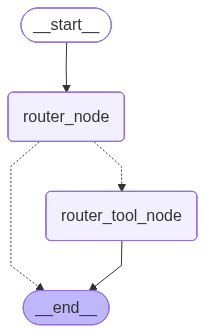

In [229]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [ ]:
# Invoke
from langchain.messages import HumanMessage

docs_titles = tree_retrieval.get_docs_titles()


query = "ممكن تقولي ايه الخبرة بتاعتك؟"

messages = agent.invoke({"user_query": query})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

ممكن تقولي ايه الخبرة بتاعتك؟
================================== Ai Message ==================================

يمكنك العثور على تفاصيل خبراتي في المستندات المتاحة.


In [231]:
messages

{'messages': [HumanMessage(content='ممكن تقولي ايه الخبرة بتاعتك؟', additional_kwargs={}, response_metadata={}),
  AIMessage(content='يمكنك العثور على تفاصيل خبراتي في المستندات المتاحة.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'user_query': 'ممكن تقولي ايه الخبرة بتاعتك؟',
 'router_outputs': {'router_answer': 'يمكنك العثور على تفاصيل خبراتي في المستندات المتاحة.',
  'need_retrieval': True,
  'tool_name': '',
  'tool_args': {}}}